## 1 概述

SLR （简单线性回归）只考虑一个特征，多个特征时就要用到多元线性回归（ Multiple Linear Regression , 简称 MLR ）。

MLR 同样有解析解公式 $W=(X^TX)^{-1}X^TY$ ，称为正规方程，其实 SLR 的解析解公式就是正规方程的特殊情况。

## 2 正规方程推导

多元线性回归的假设函数：$\hat{y}=w_1x_1+w_2x_2+...+w_mx_m+b$ ，把 $b$ 看成 $w_0$ ，对应 $x_0=1$，那么可以用向量表示：
$$
\hat{y}_i=X_iW \quad,\quad 其中\ X_i=[1,x_1,x_2,...,x_m],\ W=[w_0,w_1,w_2,...,w_m]^T
$$
> 这里的向量 $W$ 又称**权重**。  

接着把 $\hat{y}_i$ 向量表示为 $\hat{Y}$，把 $X_i$ 矩阵表示为 $X$ ，那么假设函数的矩阵形式就是：
$$
\hat{Y}=XW \quad,\quad 其中\ \hat{Y}=[\hat{y}_1,\hat{y}_2,...,\hat{y}_n]^T,\ X_{n\times m}=\begin{pmatrix} X_1 \\ X_2 \\ ... \\ X_n \end{pmatrix}
$$

残差也可以用向量表示：$e=Y-\hat{Y}=Y-XW$ ，可以推出：
$$
e^Te=\begin{pmatrix} e_1 && e_2 && ... && e_n \end{pmatrix} \begin{pmatrix} e_1 \\ e_2 \\ ... \\ e_n \end{pmatrix}=e_1^2+e_2^2+...+e_n^2=\sum_{i=1}^n(y_i-\hat{y}_i)^2
$$

所以代价函数的矩阵形式为 $J(W)=\frac{1}{n}\sum(y_i-\hat{y})^2=\frac{1}{n}(Y-XW)^T(Y-XW)$

已知**和的转置等于转置的和**，因此：
$$
J(W)=\frac{1}{n}(Y^T-W^TX^T)(Y-XW)=\frac{1}{n}(Y^TY-Y^TXW-W^TX^TY+W^TX^TXW)
$$

看中间两项是互为转置的：$(Y^TXW)^T=W^TX^TY$

已知 $Y_{n\times 1},X_{n\times m},W_{m\times 1}$ ，故 $Y^TXW,W^TX^TY$ 都是 $1\times 1$ 的标量，即一个数，一个数的转置是它本身：$(Y^TXW)^T=Y^TXW$

因此这两项是相等的：$Y^TXW=W^TX^TY$ ，因此：
$$
J(W)=\frac{1}{n}(Y^TY-2W^TX^TY+W^TX^TXW)
$$

要找 $J(W)$ 的最低点，就要对其求导，并使导数等于零；需要先了解两个矩阵求导的法则：
1. $(W^TAW)_W^{'}=(A+A^T)W$ ，成立条件：$A$ 与 $W$ 无关；若 $A$ 是对称矩阵则结果是 $2AW$
2. $(W^TB)_W^{'}=B$ ，成立条件：$B$ 是一个常数向量且与 $W$ 无关

把式中的 $X^TX$ 可以看作 $A$，且这是一个对称矩阵 $(X^TX)^T=X^TX$ ；式中 $X^TY$ 看作 $B$ ；所以 $J(W)$ 求导并使其为零：
$$
\frac{\partial J}{\partial W}=-2X^TY+2X^TXW=0 \implies X^TXW=X^TY
$$

> 把 $X^T$ 提出来，把不影响结果的系数去掉，可得：$\frac{\partial J}{\partial W}=X^T(XW-Y)=X^T(\hat{Y}-Y)$ ，这个式子在后续逻辑回归、神经网络等都会用到。

两边左乘 $(X^TX)^{-1}$ ，可得正规方程：
$$
W=(X^TX)^{-1}X^TY
$$

从数学角度严格来说，正规方程必须 $X^TX$ 可逆，这需要特征数小于样本数 $m<n$ ，且特征之间线性无关；但现实世界的数据几乎必然存在相关性，比如：身高和体重、面积和房间数；因此在实现中，分情况处理： 
1. 低维且轻度线性相关：不会直接求逆，而是通过 SVD（奇异值分解）进行求解，即使不可逆（有无穷多解）也能给出最小范数解，sklearn 就是这么做的。
1. 低维且存在严重的线性相关：在代价函数中引入正则化项，保证矩阵可逆，比如：岭回归。
1. 高维数据（特征数或样本量级极大），由于 $O(m^3)$ 的计算量过大，不考虑用正规方程求解析解，采用梯度下降迭代逼近数值解。



## 3 数据集

继续用鲍鱼数据集 (Abalone Dataset)，这次将一步步把全部八个特征都用上。

处理数据集并划分训练集（占 80%）和测试集（占 20%）

In [ ]:
import pandas as pd
import os

names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df = pd.read_csv('./datasets/abalone/abalone.data', header=None, names=names)
out_dir = './outputs/mlr'
os.makedirs(out_dir, exist_ok=True)
df.to_csv(f'{out_dir}/abalone_processed.csv', index=False)
# 打乱数据（frac=1 表示抽取 100% 的行，random_state=42 设置随机种子保证结果可复现）
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
# 计算切分位置
split_idx = int(len(df_shuffled) * 0.8)
# 按位置切分
df_train = df_shuffled.iloc[:split_idx]
df_test = df_shuffled.iloc[split_idx:]
# 保存切分好的训练集和测试集
df_train.to_csv(f'{out_dir}/abalone_train.csv', index=False)
df_test.to_csv(f'{out_dir}/abalone_test.csv', index=False)

## 4 评估指标

在特征值较多时，很难通过画图展示效果，这个时候就需要评估指标来判断模型的效果，下面是回归算法中最常用的三个评估指标：
1. $R^2$ ：Coefficient of Determination （决定系数），计算公式 $1-\frac{模型误差}{直接猜均值的误差}$ ，表示模型比瞎猜强了多少，最大值1，负数代表不如瞎猜。
1. $MAE$ ：Mean Absolute Error（平均绝对误差），计算公式 $\frac{1}{n}\sum|y_i-\hat{y}_i|$ ，表示平均每只鲍鱼猜差了几环，非常直观的指标，适合讲给非技术人员听。
1. $RMSE$ ：Root Mean Squared Error（均方根误差），计算公式 $\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$ ，对大误差敏感，判断是否少量预测严重跑偏。

## 5 算法演示

### 5.1 单个特征
先用一个特征进行训练和评估，看看效果：

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 准备数据并训练模型
df_train = pd.read_csv(f'{out_dir}/abalone_train.csv')
features = ['Shell_weight']
X_train = df_train[features]
y_train = df_train['Rings']
model = LinearRegression()  # 线性回归
model.fit(X_train, y_train)
# 提取训练好的参数，即直线的参数
w = model.coef_
b = model.intercept_
print("训练完成，拟合方程系数：")
for name, coef in zip(features, w):
    print(f"  {name:20s} : {coef:.6f}")
print(f"截距 (Intercept) : {b:.6f}")
# 在测试集用训练好的模型预测，并评估结果
df_test = pd.read_csv(f'{out_dir}/abalone_test.csv')
X_test = df_test[features]
y_test = df_test['Rings']
y_pred = model.predict(X_test)  # 用训练好的模型预测
# 计算三个评估指标
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("========== 测试集评估结果 ==========")
print(f"R²  (决定系数)       : {r2:.4f}")
print(f"MAE (平均绝对误差)   : {mae:.2f} 环")
print(f"RMSE(均方根误差)     : {rmse:.2f} 环")
print("====================================")

训练完成，拟合方程系数：
  Shell_weight         : 14.928140
截距 (Intercept) : 6.392470
========== 测试集评估结果 ==========
R²  (决定系数)       : 0.3358
MAE (平均绝对误差)   : 1.78 环
RMSE(均方根误差)     : 2.38 环


### 5.2 七个特征

下面用除 Sex 以外的七个特征：

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 准备数据并训练模型
df_train = pd.read_csv(f'{out_dir}/abalone_train.csv')
# 调整纳入训练的特征，只需要改这一行即可
features = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
X_train = df_train[features]
y_train = df_train['Rings']
model = LinearRegression()  # 线性回归
model.fit(X_train, y_train)
# 提取训练好的参数
w = model.coef_
b = model.intercept_
print("训练完成，拟合方程系数：")
for name, coef in zip(features, w):
    print(f"  {name:20s} : {coef:.6f}")
print(f"截距 (Intercept) : {b:.6f}")
# 在测试集用训练好的模型预测，并评估结果
df_test = pd.read_csv(f'{out_dir}/abalone_test.csv')
X_test = df_test[features]
y_test = df_test['Rings']
y_pred = model.predict(X_test)  # 用训练好的模型预测
# 计算三个评估指标
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("========== 测试集评估结果 ==========")
print(f"R²  (决定系数)       : {r2:.4f}")
print(f"MAE (平均绝对误差)   : {mae:.2f} 环")
print(f"RMSE(均方根误差)     : {rmse:.2f} 环")
print("====================================")

训练完成，拟合方程系数：
  Length               : -1.542594
  Diameter             : 13.732176
  Height               : 10.600512
  Whole_weight         : 9.079121
  Shucked_weight       : -20.077852
  Viscera_weight       : -9.709672
  Shell_weight         : 9.002490
截距 (Intercept) : 2.953835
========== 测试集评估结果 ==========
R²  (决定系数)       : 0.5167
MAE (平均绝对误差)   : 1.49 环
RMSE(均方根误差)     : 2.03 环


可以看到七个特征的结果有明显提升。

### 5.3 独热编码

最后把 Sex 特征也加上，由于是分类变量，不能直接作为数值特征纳入训练，需要做独热编码（One-Hot Encoding），本例 Sex 有三个类别 F, M, I ，它会怎么编码呢：
1. Sex 这一个特征转化为三列 Sex_F, Sex_I, Sex_M
1. 若样本性别为 F 则赋值为 1, 0, 0
1. 若样本性别为 I 则赋值为 0, 1, 0
1. 若样本性别为 M 则赋值为 0, 0, 1

但这样会有个问题，这三列在每个样本中加起来都等于 1 ，这意味着信息是冗余的，是线性相关的（在上文`2 正规方程推导`中可知矩阵中表达 $x_0$ 那一列是全 1 的），矩阵会因不满秩而无法求逆，但实际用 sklearn 求解是没问题的，因为现实世界的数据几乎都存在一定程度的相关，所以实现正规方程求解时不是直接求逆，而是通过 SVD （奇异值分解）找最小范数解。

是不是有更好的做法呢？有，就是删除一个类别，比如删除第一列 Sex_F ，那就变成了：
- 0, 0 代表性别 F
- 1, 0 代表性别 I
- 0, 1 代表性别 M

两列即可表示三个类别，这样就没有信息冗余、线性相关的问题了，所以下文代码中用了 drop_first=True ，由于默认按字母排序，因此系数中没有 Sex_F 。

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 准备数据并训练模型
df_train = pd.read_csv(f'{out_dir}/abalone_train.csv')
features = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
feature_sex = ['Sex']
X_train = df_train[features].copy() # 数值类特征
# 将数值类特征、独热编码后的 Sex 合并到一起
X_train = pd.concat([X_train, pd.get_dummies(df_train[feature_sex], prefix='Sex', drop_first=True)], axis=1)
y_train = df_train['Rings']
model = LinearRegression()  # 线性回归
model.fit(X_train, y_train)
# 提取训练好的参数
w = model.coef_
b = model.intercept_
print("训练完成，拟合方程系数：")
for name, coef in zip(X_train.columns, w):
    print(f"  {name:20s} : {coef:.6f}")
print(f"截距 (Intercept) : {b:.6f}")
# 在测试集用训练好的模型预测，并评估结果
df_test = pd.read_csv(f'{out_dir}/abalone_test.csv')
X_test = df_test[features].copy()   # 数值类特征
# 将数值类特征、独热编码后的 Sex 合并到一起
X_test = pd.concat([X_test, pd.get_dummies(df_test[feature_sex], prefix='Sex', drop_first=True)], axis=1)
# 确保测试集的列顺序与训练集完全一致（防止因类别缺失导致列错位）
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = df_test['Rings']
y_pred = model.predict(X_test)  # 用训练好的模型预测
# 计算三个评估指标
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("========== 测试集评估结果 ==========")
print(f"R²  (决定系数)       : {r2:.4f}")
print(f"MAE (平均绝对误差)   : {mae:.2f} 环")
print(f"RMSE(均方根误差)     : {rmse:.2f} 环")
print("====================================")

训练完成，拟合方程系数：
  Length               : -0.460298
  Diameter             : 11.502971
  Height               : 9.648929
  Whole_weight         : 8.726783
  Shucked_weight       : -19.590790
  Viscera_weight       : -10.420229
  Shell_weight         : 9.241635
  Sex_I                : -0.821451
  Sex_M                : 0.102966
截距 (Intercept) : 3.841759
========== 测试集评估结果 ==========
R²  (决定系数)       : 0.5258
MAE (平均绝对误差)   : 1.46 环
RMSE(均方根误差)     : 2.01 环


## 6 迭代求解

前面用正规方程求解 MLR ，一步就得到了权重 W ，但正规方程有两个限制：
1. 矩阵可逆要求特征之间线性无关，但现实中特征往往存在着复杂的相关性，虽然 SVD 可以给出最小范数解，但权重的解释性会变差。
1. 计算量：求 $(X^TX)^{-1}$ 的复杂度是 $O(M^3)$ ，当特征数 $m$ 很大时（比如上万），计算极慢甚至内存装不下。

因此又到了喜闻乐见的使用梯度下降迭代逼近数值解的环节：先随便猜一组权重，然后计算代价函数 J(W) ，再沿着 J(W) 下降最快的方向（负梯度方向）逐步更新 W ，直到 J(W) 几乎不再下降。

### 6.1 数据标准化

当特征的数值量纲差异较大时，如果不进行标准化，梯度下降会遇到两个问题：
1. 收敛慢：大尺度的梯度比小尺度大，导致参数更新方向在特征之间不平衡，需要更小的学习率，收敛更慢。
1. 系数不可比较：比如 Whole_weight 的系数必然小于 Shell_weight ，但这不代表它的贡献小；标准化后，系数的绝对值可直接进行比较——越大表示对结果的影响越大。

> 注：以下文`6.2 手写代码`为例，经实际测试，未标准化需要迭代约80万次，耗时约50秒；标准化后只需要迭代约6万次，耗时约4秒。

标准化的公式：$x_{std}=\frac{x-\mu}{\sigma}$（ $\mu$ 为均值，$\sigma$ 为标准差 ），代码很简单：
```python
# 计算均值和标准差（axis=0 表示对每一列分别计算）
mu = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw, axis=0)
# 防止除以零（如果某列所有值相同，则 相同，sigma 为 0 ，则标准化后该列全为 0）
sigma[sigma == 0] = 1
# 标准化
X_train_std = (X_train_raw - mu) / sigma
```
`防止除以零`这步需要说下：
1. 若某列所有值相同，则 $\mu$ 也是同一个数，标准化就成了 $\frac{0}{0}$ ，加了代码 sigma[sigma==0]=1 则变成 $\frac{0}{1}$ ，那么该列就全是 0 了。
1. 全 0 有影响吗？没有，因为当一个特征在训练集上完全没有变化时，它对预测没有任何贡献，是全 0 还是全其他某个值，不会影响模型。
1. 但是，全是 1 的偏置列不一样，标准化后变成全成 0 ，那就相当于失去截距 b 了，所以**必须要在加偏置列之前标准化**。


### 6.2 手写代码

在 SLR 中手写过梯度下降，平均梯度的计算公式是：$dw=\frac{1}{n}\sum(\hat{y}_i-y_i)x_i$

在 MLR 中，特征从 1 个变成了 m 个，梯度也从一个数变成了一个向量，计算公式要用矩阵形式写：$dW=\frac{1}{n}X^T(XW-Y)$
> 对 J(W) 求导的过程可见上文的 `2 正规方程推导`

梯度下降的计算也改成矩阵形式：$W=W-lr\times dW$

计算梯度和更新参数的两行关键代码，从：
```python
dw = (1/n) * np.sum((y_pred - y) * X.flatten()) # 计算平均梯度
w = w - lr * dw                                 # 更新参数，梯度下降
```
改成：
```python
dW = (1/n) * X_train.T @ (y_pred - y)   # 计算平均梯度
W = W - lr * dW                         # 更新参数，梯度下降
```

下面是完整代码：


✅ 停止于代价变化容差：第 61235 轮，代价变化 = 5.00e-09 < 5e-09

训练完成，拟合方程系数：
  bias (intercept) : 9.931458
  Length               : -0.188154
  Diameter             : 1.371650
  Height               : 0.454302
  Whole_weight         : 4.385983
  Shucked_weight       : -4.376837
  Viscera_weight       : -1.047082
  Shell_weight         : 1.286564

Final cost J = 5.105905, total epochs = 61237

========== 测试集评估结果 ===========
R²  (决定系数)       : 0.5166
MAE (平均绝对误差)   : 1.49 环
RMSE(均方根误差)     : 2.03 环


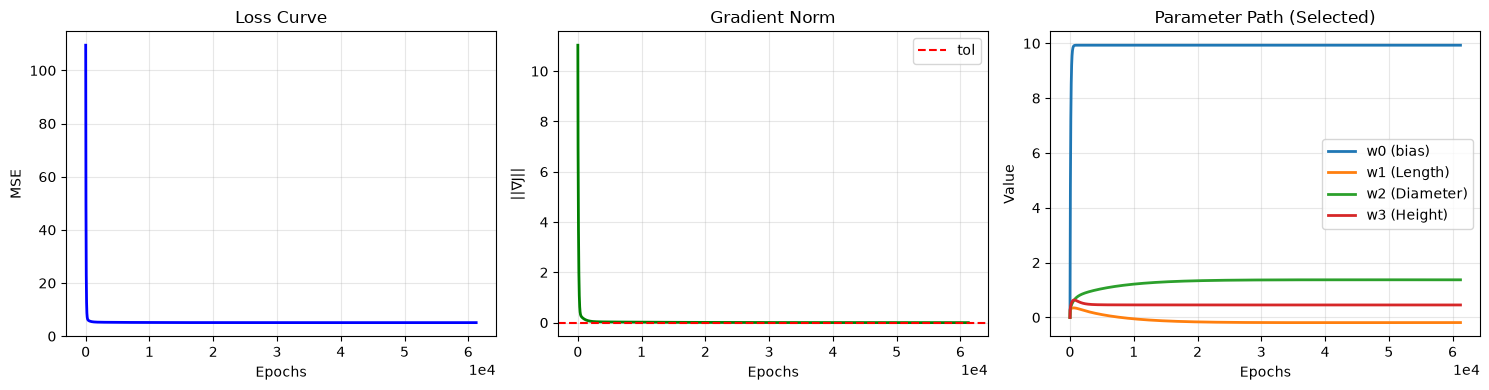

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 超参数
W_init = np.zeros(8)    # 偏置项b + 7个特征，初始权重全为零
lr = 0.01               # 学习率
tol = 5e-9              # 容差
max_epochs = 1000000    # 最大迭代次数
# 载入训练集
df_train = pd.read_csv(f'{out_dir}/abalone_train.csv')
features = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
# 构建特征矩阵（添加偏置列）
X_train_raw = df_train[features].values
# 数据标准化
mu = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw, axis=0)
sigma[sigma == 0] = 1
X_train_std = (X_train_raw - mu) / sigma
# 添加偏置列
X_train = np.c_[np.ones((X_train_std.shape[0], 1)), X_train_std]    # 左侧加全1列
y_train = df_train['Rings'].values
# 代价函数
def cost_func(W, X, Y):
    Y_pred = X @ W
    return np.mean((Y - Y_pred) ** 2)
# GD 函数
def gradient_descent(X, Y, W_init, lr, max_epochs, tol):
    W = W_init.copy()
    n = len(X)  # 样本数
    # 记录历史数据
    W_hist = [W.copy()]
    cost_hist = [cost_func(W, X, Y)]
    grad_hist = []
    param_hist = []
    # 循环进行梯度下降
    for epoch in range(max_epochs):
        Y_pred = X @ W              # 预测
        error = Y_pred - Y          # 残差
        dW = (1/n) * X.T @ error    # 平均梯度
        grad_norm = np.linalg.norm(dW)  # 梯度范数
        grad_hist.append(grad_norm)
        # 停止条件1：梯度范数小于容差
        if grad_norm < tol:
            print(f"✅ 停止于梯度容差：第 {epoch} 轮，梯度范数 = {grad_norm:.2e} < {tol}")
            break
        # 更新参数、代价，并保存
        W_new = W - lr * dW     # 更新参数
        param_change = np.linalg.norm(W_new - W)    # 参数变化量
        param_hist.append(param_change)
        cost_new = cost_func(W_new, X, Y)   # 计算新的代价值
        W = W_new
        W_hist.append(W.copy())
        cost_hist.append(cost_new)
        # 停止条件2：参数变化量小于容差
        if param_change < tol:
            print(f"✅ 停止于参数变化容差：第 {epoch} 轮，参数变化 = {param_change:.2e} < {tol}")
            break
        # 停止条件3：代价变化量小于容差
        if abs(cost_hist[-1] - cost_hist[-2]) < tol:
            print(f"✅ 停止于代价变化容差：第 {epoch} 轮，代价变化 = {abs(cost_hist[-1] - cost_hist[-2]):.2e} < {tol}")
            break
    else:
        print(f"⚠️ 达到最大迭代次数 {max_epochs}，算法未完全收敛，请考虑调整参数。")
    # 返回数据
    return {
        'epochs': len(W_hist),
        'W_hist': W_hist,
        'cost_hist': cost_hist,
        'grad_hist': grad_hist,
        'param_hist': param_hist
    }
# 运行梯度下降
history = gradient_descent(X_train, y_train, W_init, lr, max_epochs, tol)
# 绘制三个监测图
epochs = history['epochs']
W_hist = history['W_hist']
cost_hist = history['cost_hist']
grad_hist = history['grad_hist']
param_hist = history['param_hist']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 图1：损失下降曲线
axes[0].plot(range(epochs), cost_hist, color='blue', lw=2)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE')
axes[0].grid(True, alpha=0.3)
# 图2：梯度范数变化
axes[1].plot(range(len(grad_hist)), grad_hist, color='green', lw=2)
axes[1].axhline(y=tol, color='red', linestyle='--', label='tol')
axes[1].set_title('Gradient Norm')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('||∇J||')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# 图3：参数轨迹（取前四个）
W_array = np.array(W_hist)
axes[2].plot(range(epochs), W_array[:, 0], label='w0 (bias)', lw=2)
axes[2].plot(range(epochs), W_array[:, 1], label='w1 (Length)', lw=2)
axes[2].plot(range(epochs), W_array[:, 2], label='w2 (Diameter)', lw=2)
axes[2].plot(range(epochs), W_array[:, 3], label='w3 (Height)', lw=2)
axes[2].set_title('Parameter Path (Selected)')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
# 强制 X 轴刻度使用科学计数法（如 1e5, 2e5），防止数值过大时标签重叠
for ax in axes:
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.tight_layout()
plt.savefig(f'{out_dir}/gd_mlr_monitor.png', dpi=150)
# 训练结果
W_final = W_hist[-1]
print("\n训练完成，拟合方程系数：")
print(f"  bias (intercept) : {W_final[0]:.6f}")
for name, coef in zip(features, W_final[1:]):
    print(f"  {name:20s} : {coef:.6f}")
print(f"\nFinal cost J = {cost_hist[-1]:.6f}, total epochs = {epochs}")
# 在测试集用训练好的模型预测，并评估结果
df_test = pd.read_csv(f'{out_dir}/abalone_test.csv')
X_test_raw = df_test[features].values
# 数据标准化（在测试验证时要用训练集算出来的均值和标准差，因为模拟的是未来未知的新数据）
X_test_std = (X_test_raw - mu) / sigma
# 添加偏置列
X_test = np.c_[np.ones((X_test_std.shape[0], 1)), X_test_std]
y_test = df_test['Rings'].values
Y_pred = X_test @ W_final
r2 = r2_score(y_test, Y_pred)
mae = mean_absolute_error(y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(y_test, Y_pred))
print("\n========== 测试集评估结果 ===========")
print(f"R²  (决定系数)       : {r2:.4f}")
print(f"MAE (平均绝对误差)   : {mae:.2f} 环")
print(f"RMSE(均方根误差)     : {rmse:.2f} 环")
print("====================================")
plt.show()